## **GetAround Deployment Project — Jedha Bootcamp**


## **02. Pricing: EDA, Feature Engineering & Preprocessing**

### **Objectif**

Préparer les données de pricing pour l'entraînement du modèle ML. Ce notebook couvre :
1. **EDA** du dataset pricing (distributions, corrélations, outliers)
2. **Feature Engineering** (création de nouvelles features, transformations)
3. **Preprocessing** (pipeline sklearn complet, encoding, scaling)
4. **Export** des données prêtes pour le notebook de modélisation

### **1. Setup & chargement**

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

pricing_project_data = '../data/get_around_pricing_project.csv'
output_models_path = '../outputs/models'

In [32]:
df = pd.read_csv(pricing_project_data)
df = df.drop(columns=['Unnamed: 0'])  # Index inutile
df.head(10)

,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183
5,Citroën,152352,225,petrol,black,convertible,True,True,False,False,True,True,True,131
6,Citroën,205219,145,diesel,grey,convertible,True,True,False,False,True,True,True,111
7,Citroën,115560,105,petrol,white,convertible,True,True,False,False,False,True,True,78
8,Peugeot,123886,125,petrol,black,convertible,True,False,False,False,False,True,True,79
9,Citroën,139541,135,diesel,white,convertible,False,False,False,False,True,False,True,132


### **2. Data Exploration**

In [5]:
# Types
print(df.dtypes)
print()

# Catégorisation des features
cat_cols = ['model_key', 'fuel', 'paint_color', 'car_type']
bool_cols = ['private_parking_available', 'has_gps', 'has_air_conditioning',
             'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']
num_cols = ['mileage', 'engine_power']
target = 'rental_price_per_day'

print(f"Catégorielles:  {cat_cols}")
print(f"Booléennes:     {bool_cols}")
print(f"Numériques:     {num_cols}")
print(f"Target:         {target}")


model_key                      str
mileage                      int64
engine_power                 int64
fuel                           str
paint_color                    str
car_type                       str
private_parking_available     bool
has_gps                       bool
has_air_conditioning          bool
automatic_car                 bool
has_getaround_connect         bool
has_speed_regulator           bool
winter_tires                  bool
rental_price_per_day         int64
dtype: object

Catégorielles:  ['model_key', 'fuel', 'paint_color', 'car_type']
Booléennes:     ['private_parking_available', 'has_gps', 'has_air_conditioning', 'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']
Numériques:     ['mileage', 'engine_power']
Target:         rental_price_per_day


In [6]:
# Valeurs manquantes
print("Valeurs manquantes:")
print(df.isnull().sum())

Valeurs manquantes:
model_key                    0
mileage                      0
engine_power                 0
fuel                         0
paint_color                  0
car_type                     0
private_parking_available    0
has_gps                      0
has_air_conditioning         0
automatic_car                0
has_getaround_connect        0
has_speed_regulator          0
winter_tires                 0
rental_price_per_day         0
dtype: int64


In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model_key,4843,28,Citroën,969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,4843.0,NaN,NaN,NaN,140962.799504,60196.740703,-64.0,102913.5,141080.0,175195.5,1000376.0
engine_power,4843.0,NaN,NaN,NaN,128.98823,38.99336,0.0,100.0,120.0,135.0,423.0
fuel,4843,4,diesel,4641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paint_color,4843,10,black,1633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
car_type,4843,8,estate,1606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
private_parking_available,4843,2,True,2662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_gps,4843,2,True,3839,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_air_conditioning,4843,2,False,3865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
automatic_car,4843,2,False,3881,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Stats descriptives numériques
df[num_cols + [target]].describe().round(1)

,mileage,engine_power,rental_price_per_day
count,4843.0,4843.0,4843.0
mean,140962.8,129.0,121.2
std,60196.7,39.0,33.6
min,-64.0,0.0,10.0
25%,102913.5,100.0,104.0
50%,141080.0,120.0,119.0
75%,175195.5,135.0,136.0
max,1000376.0,423.0,422.0


### **3. Analyse de données**

#### **3.1. EDA - Variable cible**

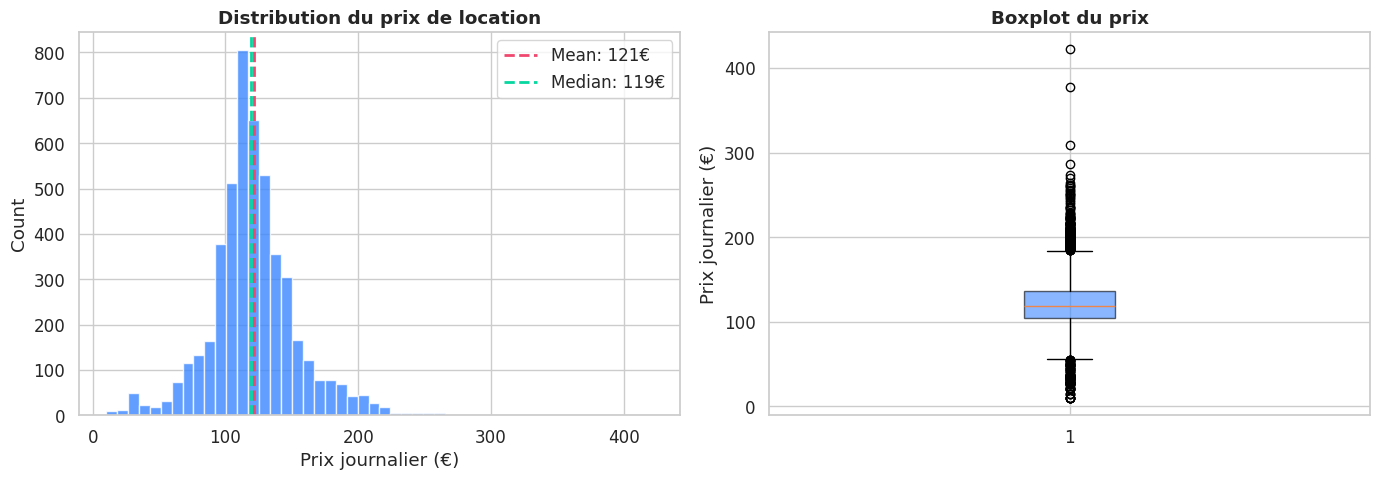

Prix - Mean: 121.2€, Std: 33.6€
Range: 10€ - 422€
Q1: 104€, Q3: 136€
IQR: 32€


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution du prix
axes[0].hist(df[target], bins=50, color='#3a86ff', alpha=0.8, edgecolor='white')
axes[0].axvline(df[target].mean(), color='#ef476f', linestyle='--', linewidth=2,
                label=f'Mean: {df[target].mean():.0f}€')
axes[0].axvline(df[target].median(), color='#06d6a0', linestyle='--', linewidth=2,
                label=f'Median: {df[target].median():.0f}€')
axes[0].set_xlabel('Prix journalier (€)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution du prix de location', fontweight='bold')
axes[0].legend()

# Boxplot
axes[1].boxplot(df[target], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3a86ff', alpha=0.6))
axes[1].set_ylabel('Prix journalier (€)')
axes[1].set_title('Boxplot du prix', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Prix - Mean: {df[target].mean():.1f}€, Std: {df[target].std():.1f}€")
print(f"Range: {df[target].min()}€ - {df[target].max()}€")
print(f"Q1: {df[target].quantile(0.25):.0f}€, Q3: {df[target].quantile(0.75):.0f}€")
print(f"IQR: {df[target].quantile(0.75) - df[target].quantile(0.25):.0f}€")


#### **3.2. EDA - Features catégorielles**

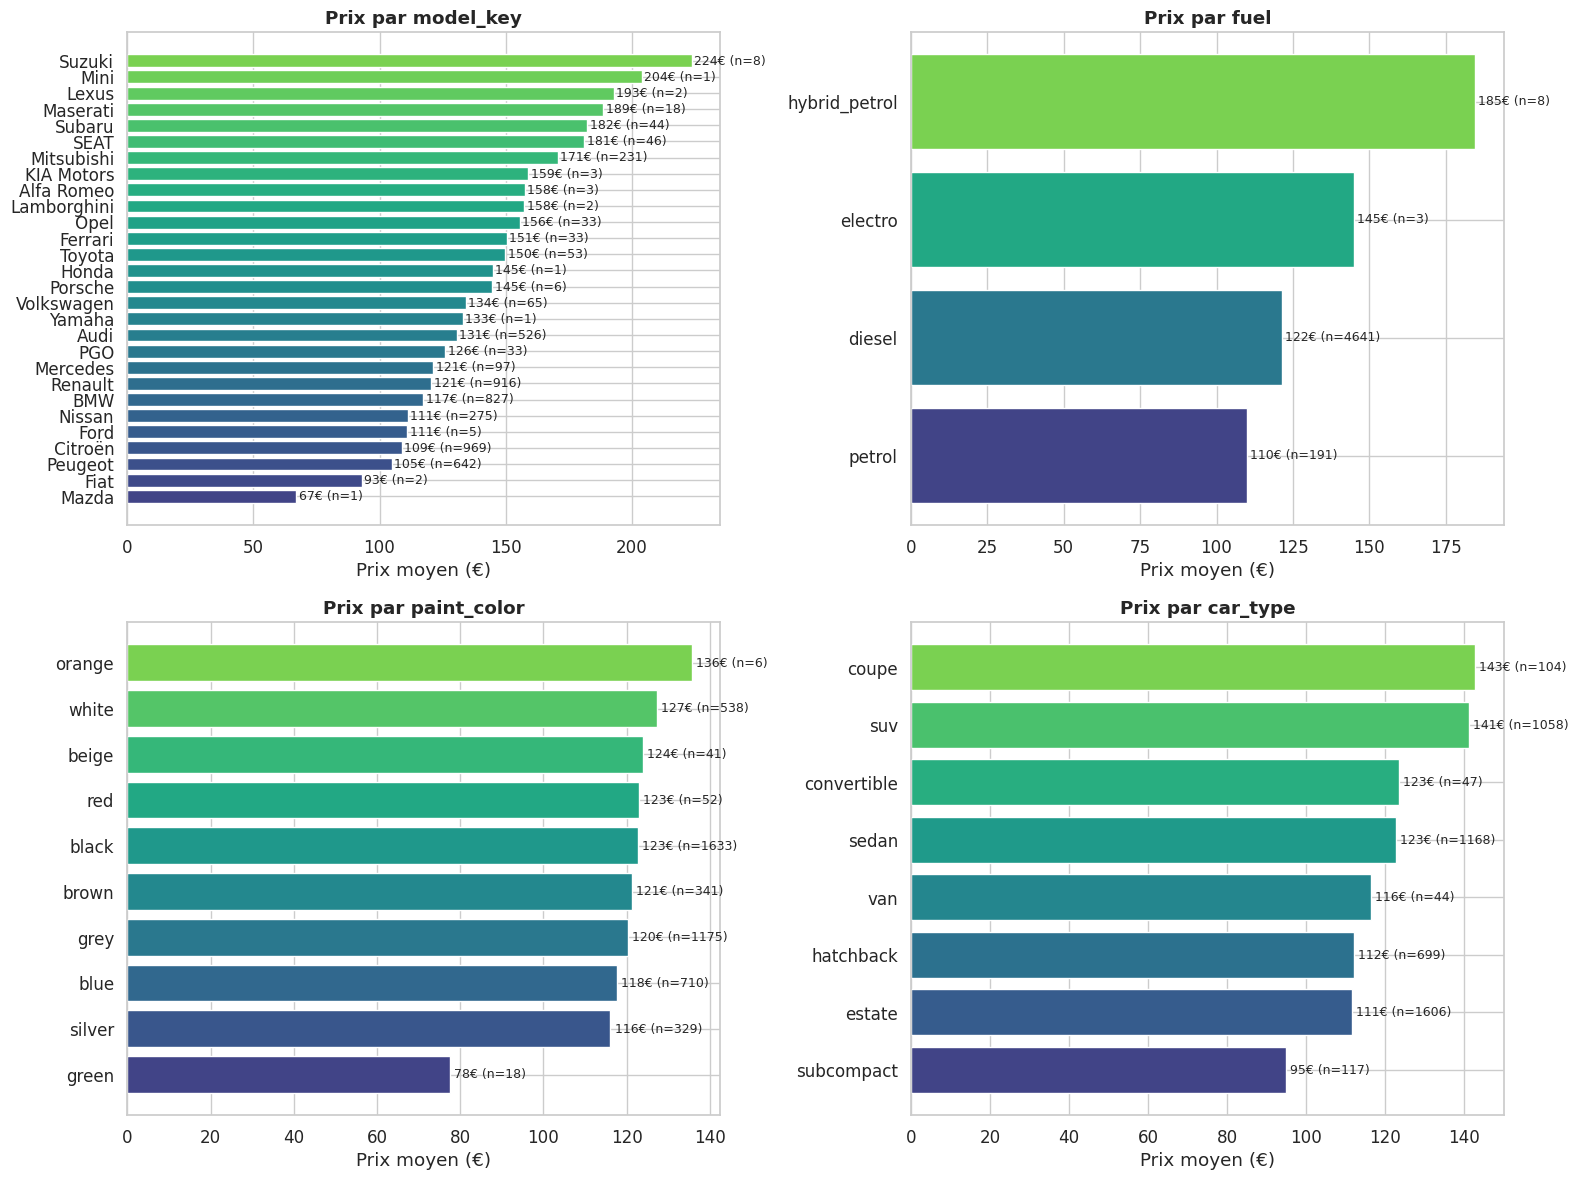

In [11]:
# Distribution + prix moyen par feature catégorielle
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, col in zip(axes.flat, cat_cols):
    stats = df.groupby(col)[target].agg(['mean', 'count']).sort_values('mean', ascending=True)
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(stats)))
    bars = ax.barh(stats.index, stats['mean'], color=colors, edgecolor='white')
    ax.set_xlabel('Prix moyen (€)')
    ax.set_title(f'Prix par {col}', fontweight='bold')
    
    # Annoter avec le count
    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{row["mean"]:.0f}€ (n={int(row["count"])})', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
# Top 15 marques par prix moyen
brand_stats = df.groupby('model_key')[target].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
print("TOP 15 MARQUES PAR PRIX MOYEN:")
print(brand_stats.head(15).round(1).to_string())
print(f"\nTotal marques: {df['model_key'].nunique()}")
print(f"\nAttention: certaines marques ont très peu d'observations (Suzuki=8, Mini=1)")
print("=> Le modèle devra gérer la rareté (OHE + régularisation ou regroupement)")

TOP 15 MARQUES PAR PRIX MOYEN:
              mean   std  count
model_key                      
Suzuki       223.9  34.0      8
Mini         204.0   NaN      1
Lexus        193.0   0.0      2
Maserati     188.7  47.5     18
Subaru       182.3  35.4     44
SEAT         181.2  32.8     46
Mitsubishi   170.7  37.9    231
KIA Motors   159.0  11.1      3
Alfa Romeo   157.7   0.6      3
Lamborghini  157.5  16.3      2
Opel         155.6  15.9     33
Ferrari      150.5  34.0     33
Toyota       149.8  44.6     53
Honda        145.0   NaN      1
Porsche      144.7  13.7      6

Total marques: 28

Attention: certaines marques ont très peu d'observations (Suzuki=8, Mini=1)
=> Le modèle devra gérer la rareté (OHE + régularisation ou regroupement)


#### **3.3. EDA - Features booléennes**

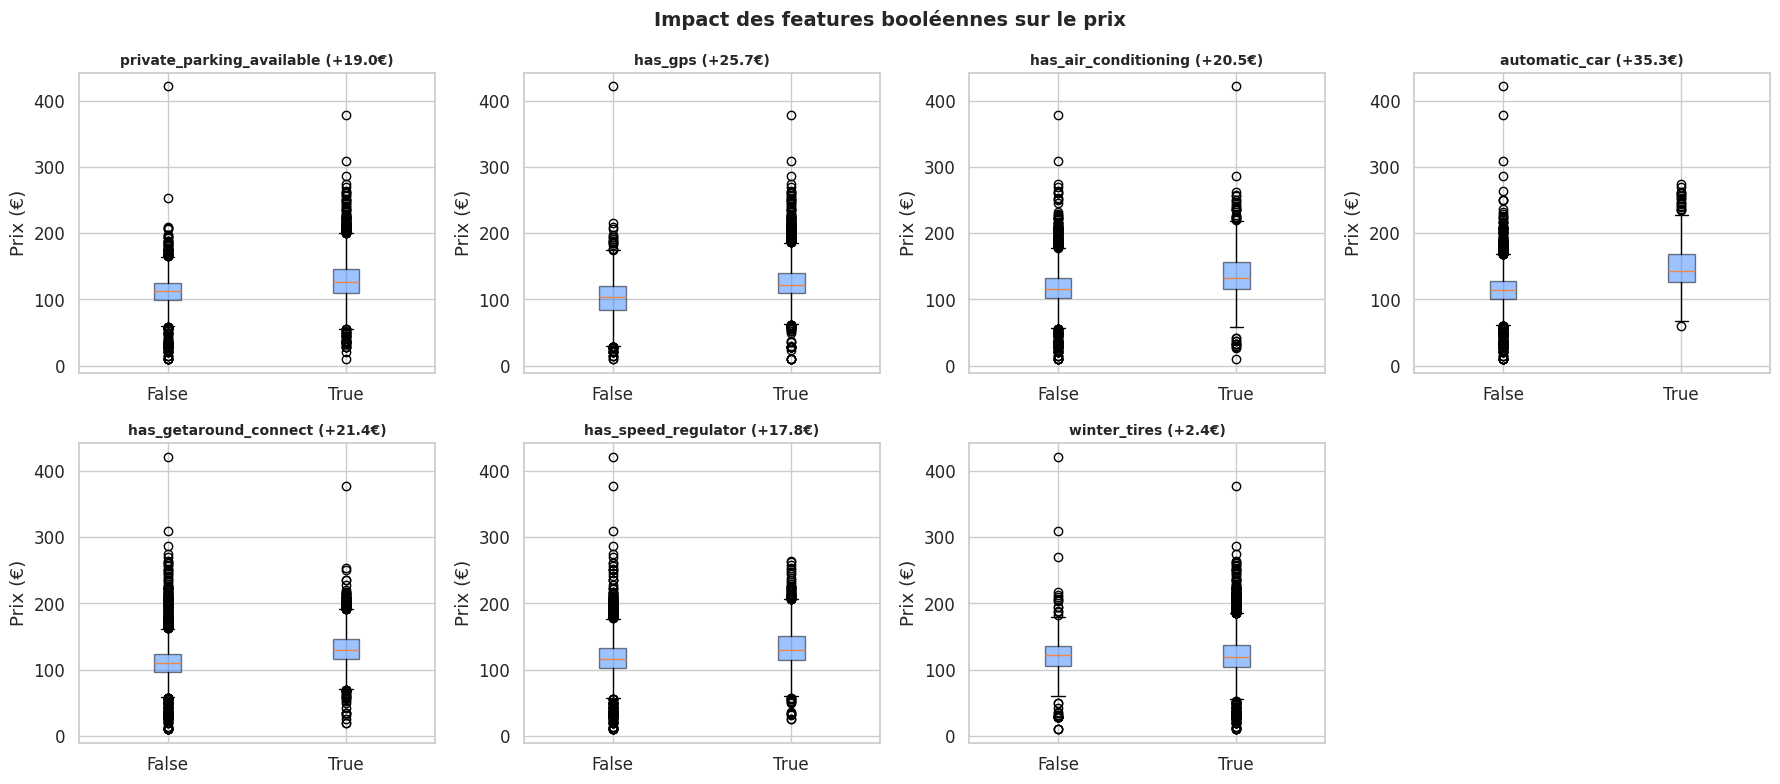

In [14]:
# Impact des features booléennes sur le prix
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flat

for i, col in enumerate(bool_cols):
    ax = axes[i]
    price_true = df[df[col] == True][target]
    price_false = df[df[col] == False][target]
    
    ax.boxplot([price_false, price_true], labels=['False', 'True'],
               patch_artist=True,
               boxprops=dict(facecolor='#3a86ff', alpha=0.5))
    
    diff = price_true.mean() - price_false.mean()
    ax.set_title(f'{col} ({diff:+.1f}€)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Prix (€)')

# Masquer le dernier subplot vide
axes[7].axis('off')
plt.suptitle('Impact des features booléennes sur le prix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Tableau récapitulatif
print("IMPACT DES FEATURES BOOLÉENNES SUR LE PRIX MOYEN:")

impacts = []
for col in bool_cols:
    yes = df[df[col] == True][target].mean()
    no = df[df[col] == False][target].mean()
    diff = yes - no
    impacts.append({'feature': col, 'True_mean': round(yes, 1), 'False_mean': round(no, 1), 
                    'diff_€': round(diff, 1)})

impact_df = pd.DataFrame(impacts).sort_values('diff_€', ascending=False)
print(impact_df.to_string(index=False))
print()
print("=> automatic_car (+35.3€), has_gps (+25.7€), has_getaround_connect (+21.4€)")
print("sont les plus discriminantes. winter_tires (+2.4€) n'a presque pas d'impact.")


IMPACT DES FEATURES BOOLÉENNES SUR LE PRIX MOYEN:
                  feature  True_mean  False_mean  diff_€
            automatic_car      149.5       114.2    35.3
                  has_gps      126.6       100.8    25.7
    has_getaround_connect      132.8       111.3    21.4
     has_air_conditioning      137.6       117.1    20.5
private_parking_available      129.8       110.8    19.0
      has_speed_regulator      134.8       116.9    17.8
             winter_tires      121.4       118.9     2.4

=> automatic_car (+35.3€), has_gps (+25.7€), has_getaround_connect (+21.4€)
sont les plus discriminantes. winter_tires (+2.4€) n'a presque pas d'impact.


#### **3.4. EDA - Features numériques**

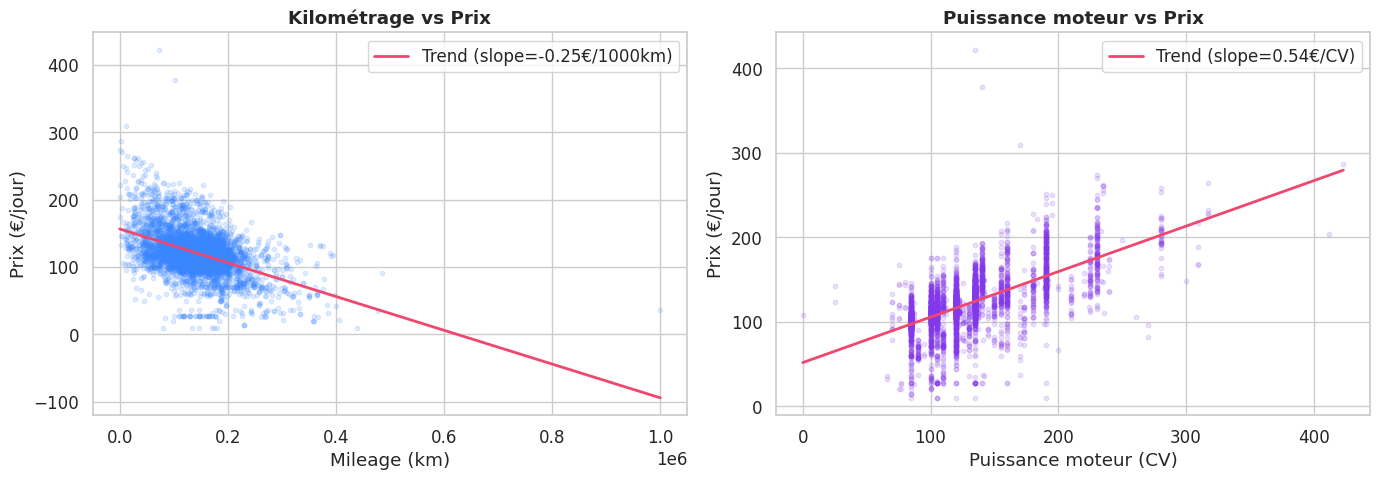

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mileage vs Price
axes[0].scatter(df['mileage'], df[target], alpha=0.15, s=10, color='#3a86ff')
z = np.polyfit(df['mileage'], df[target], 1)
p = np.poly1d(z)
x_line = np.linspace(df['mileage'].min(), df['mileage'].max(), 100)
axes[0].plot(x_line, p(x_line), color='#ef476f', linewidth=2, label=f'Trend (slope={z[0]*1000:.2f}€/1000km)')
axes[0].set_xlabel('Mileage (km)')
axes[0].set_ylabel('Prix (€/jour)')
axes[0].set_title('Kilométrage vs Prix', fontweight='bold')
axes[0].legend()

# Engine power vs Price
axes[1].scatter(df['engine_power'], df[target], alpha=0.15, s=10, color='#8338ec')
z2 = np.polyfit(df['engine_power'], df[target], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(0, df['engine_power'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), color='#ef476f', linewidth=2, label=f'Trend (slope={z2[0]:.2f}€/CV)')
axes[1].set_xlabel('Puissance moteur (CV)')
axes[1].set_ylabel('Prix (€/jour)')
axes[1].set_title('Puissance moteur vs Prix', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Corrélations numériques
print("CORRÉLATIONS AVEC LE PRIX:")
num_all = df.select_dtypes(include=[np.number]).columns
corr = df[num_all].corr()[target].drop(target).sort_values(ascending=False)
print(corr.round(3).to_string())
print()
print("=> engine_power (0.626) = corrélation la plus forte")
print("=> mileage (-0.449) = corrélation négative attendue (plus de km = moins cher)")


CORRÉLATIONS AVEC LE PRIX:
engine_power    0.626
mileage        -0.449

=> engine_power (0.626) = corrélation la plus forte
=> mileage (-0.449) = corrélation négative attendue (plus de km = moins cher)


### **4. Détection d'outliers & Data Quality**

In [19]:
# Mileage
print(f"Mileage < 0:        {(df['mileage'] < 0).sum()} observations")
print(f"Mileage > 500k:     {(df['mileage'] > 500000).sum()} observations")
if (df['mileage'] < 0).any():
    print(f"  -> Valeurs négatives: {df[df['mileage'] < 0]['mileage'].values}")

print()

# Engine power  
print(f"Engine power == 0:  {(df['engine_power'] == 0).sum()} observations")
print(f"Engine power > 400: {(df['engine_power'] > 400).sum()} observations")

print()

# Price
print(f"Price < 20€:        {(df[target] < 20).sum()} observations")
print(f"Price > 300€:       {(df[target] > 300).sum()} observations")
print(f"Price > 400€:       {(df[target] > 400).sum()} observations")


Mileage < 0:        1 observations
Mileage > 500k:     1 observations
  -> Valeurs négatives: [-64]

Engine power == 0:  1 observations
Engine power > 400: 2 observations

Price < 20€:        10 observations
Price > 300€:       3 observations
Price > 400€:       1 observations


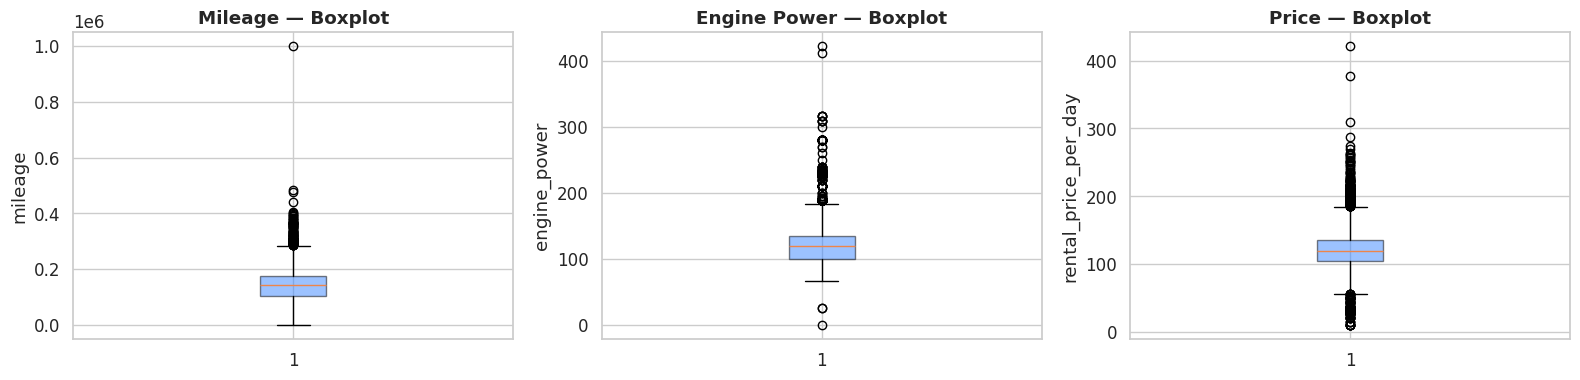

In [20]:
# Visualisation des outliers
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(axes, ['mileage', 'engine_power', target],
                          ['Mileage', 'Engine Power', 'Price']):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='#3a86ff', alpha=0.5))
    ax.set_title(f'{title} — Boxplot', fontweight='bold')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

### **5. Feature Engineering**

#### **5.1 Nouvelles features potentielles**

In [21]:
# Feature engineering
df_feat = df.copy()

# 1. Mileage buckets (non-linéarité)
df_feat['mileage_bucket'] = pd.cut(df_feat['mileage'], 
    bins=[-np.inf, 50000, 100000, 150000, 200000, np.inf],
    labels=['<50k', '50-100k', '100-150k', '150-200k', '200k+'])

# 2. Power bucket
df_feat['power_bucket'] = pd.cut(df_feat['engine_power'],
    bins=[-np.inf, 80, 120, 160, 200, np.inf],
    labels=['<80', '80-120', '120-160', '160-200', '200+'])

# 3. Nombre total d'équipements (features bool)
df_feat['n_equipments'] = df_feat[bool_cols].sum(axis=1)

# 4. Brand tier (regroupement des marques rares)
brand_counts = df_feat['model_key'].value_counts()
rare_brands = brand_counts[brand_counts < 20].index.tolist()
df_feat['brand_tier'] = df_feat['model_key'].apply(
    lambda x: 'rare_brand' if x in rare_brands else x
)

# Vérification
print(f"\nmileage_bucket distribution:")
print(df_feat['mileage_bucket'].value_counts().sort_index())
print(f"\npower_bucket distribution:")
print(df_feat['power_bucket'].value_counts().sort_index())
print(f"\nn_equipments distribution:")
print(df_feat['n_equipments'].value_counts().sort_index())
print(f"\nbrand_tier: {df_feat['brand_tier'].nunique()} catégories (vs {df_feat['model_key'].nunique()} originales)")
print(f"Rare brands regroupées: {rare_brands}")


mileage_bucket distribution:
mileage_bucket
<50k         281
50-100k      856
100-150k    1593
150-200k    1552
200k+        561
Name: count, dtype: int64

power_bucket distribution:
power_bucket
<80          32
80-120     2642
120-160    1478
160-200     432
200+        259
Name: count, dtype: int64

n_equipments distribution:
n_equipments
0     237
1     358
2     883
3    1102
4    1022
5     714
6     423
7     104
Name: count, dtype: int64

brand_tier: 16 catégories (vs 28 originales)
Rare brands regroupées: ['Maserati', 'Suzuki', 'Porsche', 'Ford', 'KIA Motors', 'Alfa Romeo', 'Fiat', 'Lamborghini', 'Lexus', 'Honda', 'Mazda', 'Mini', 'Yamaha']


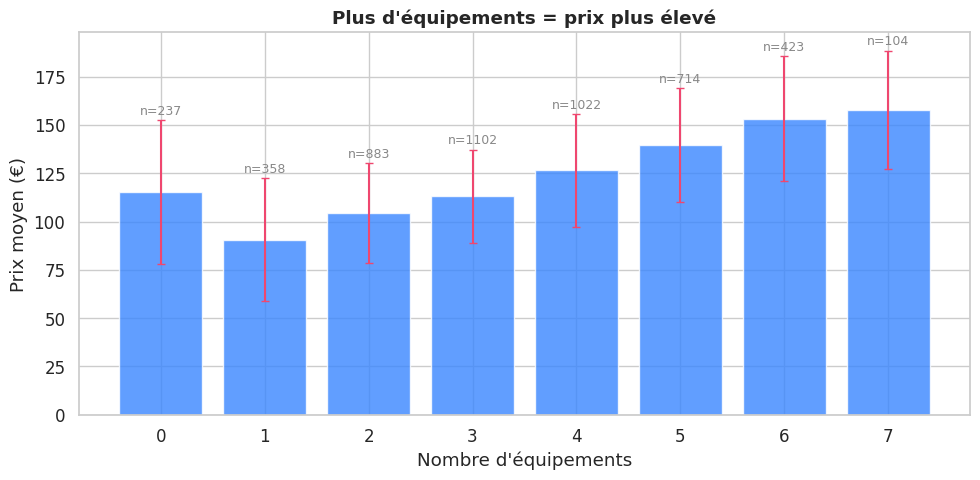

=> Tendance claire: chaque équipement supplémentaire augmente le prix de ~10-15€
Cette feature capture une information agrégée intéressante pour le modèle.


In [23]:
# Impact du nombre d'équipements sur le prix
fig, ax = plt.subplots(figsize=(10, 5))
equip_price = df_feat.groupby('n_equipments')[target].agg(['mean', 'std', 'count'])
ax.bar(equip_price.index, equip_price['mean'], color='#3a86ff', alpha=0.8, edgecolor='white')
ax.errorbar(equip_price.index, equip_price['mean'], yerr=equip_price['std'],
            fmt='none', color='#ef476f', linewidth=1.5, capsize=3)

for i, row in equip_price.iterrows():
    ax.text(i, row['mean'] + row['std'] + 3, f'n={int(row["count"])}',
            ha='center', fontsize=9, color='#888')

ax.set_xlabel('Nombre d\'équipements')
ax.set_ylabel('Prix moyen (€)')
ax.set_title('Plus d\'équipements = prix plus élevé', fontweight='bold')
plt.tight_layout()
plt.show()

print("=> Tendance claire: chaque équipement supplémentaire augmente le prix de ~10-15€")
print("Cette feature capture une information agrégée intéressante pour le modèle.")

#### **5.2 Analyse des interactions**

> Certaines combinaisons de features peuvent avoir un effet non-linéaire.
> Les modèles d'arbres les capturent nativement, mais c'est utile de les documenter.

In [24]:
# Fuel x Car type (prix moyen)
ct = pd.crosstab(df['car_type'], df['fuel'], values=df[target], aggfunc='mean')
print("Prix moyen par fuel x car_type:")
print(ct.round(1).to_string())
print()
print("=> Les hybrides/électriques sont plus chers, mais très peu de données")
print("diesel domine (96% des observations)")

Prix moyen par fuel x car_type:
fuel         diesel  electro  hybrid_petrol  petrol
car_type                                           
convertible   132.1      NaN            NaN   110.6
coupe         140.4      NaN          309.0   144.2
estate        111.7      NaN            NaN   103.3
hatchback     112.2    145.0          133.0   105.6
sedan         123.9      NaN          145.0   100.2
subcompact     94.6      NaN          167.0    87.7
suv           141.1      NaN          197.0   138.7
van           115.8      NaN            NaN   129.5

=> Les hybrides/électriques sont plus chers, mais très peu de données
diesel domine (96% des observations)


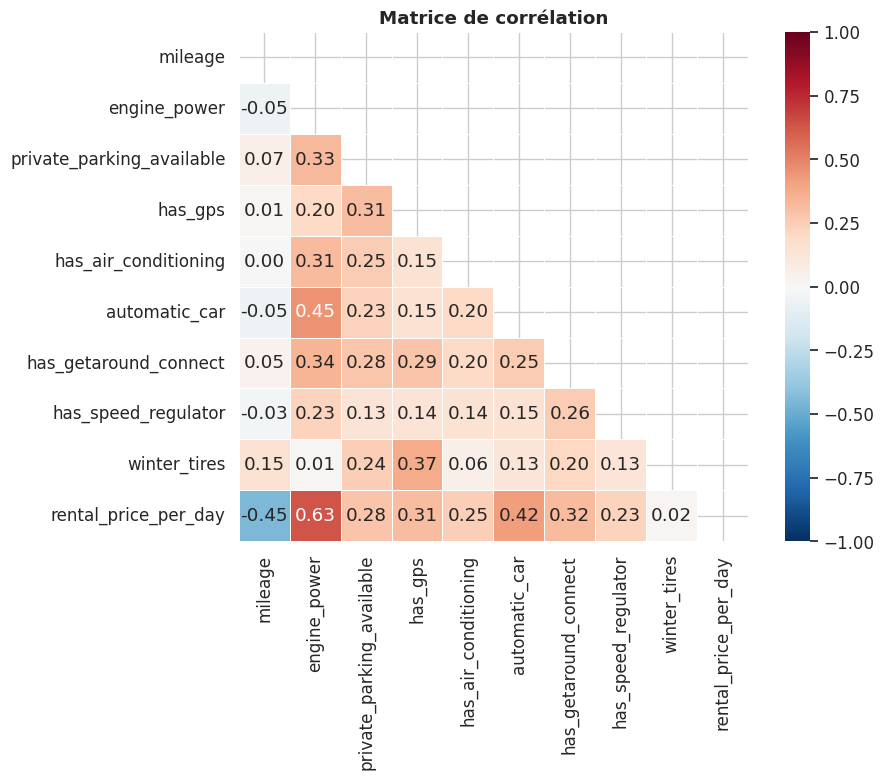

In [25]:
# Heatmap des corrélations complètes
fig, ax = plt.subplots(figsize=(10, 8))

# Encoder les bool en int pour la corrélation
df_corr = df.copy()
for col in bool_cols:
    df_corr[col] = df_corr[col].astype(int)

corr_matrix = df_corr[num_cols + bool_cols + [target]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', center=0,
            cmap='RdBu_r', vmin=-1, vmax=1, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Matrice de corrélation', fontweight='bold')
plt.tight_layout()
plt.show()


### **6. Preprocessing Pipeline**

### **Stratégie**
- **Numériques:** `StandardScaler` (normalisation pour Ridge, neutre pour arbres)
- **Catégorielles:** `OneHotEncoder` avec `handle_unknown='ignore'` (robustesse en production)
- **Booléennes:** Passthrough (déjà 0/1)
- **Pipeline sklearn:** Reproductible, sérialisable, prêt pour le déploiement

In [28]:
# Séparation features / target
X = df.drop(columns=[target])
y = df[target]

# Définition des colonnes
cat_cols = ['model_key', 'fuel', 'paint_color', 'car_type']
bool_cols = ['private_parking_available', 'has_gps', 'has_air_conditioning',
             'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']
num_cols = ['mileage', 'engine_power']

print(f"Features: {X.shape[1]}")
print(f"- Numériques: {len(num_cols)}")
print(f"- Catégorielles: {len(cat_cols)} -> {sum(X[col].nunique() for col in cat_cols)} modalités en OHE")
print(f"- Booléennes: {len(bool_cols)}")
print(f"\nTarget: {target}")

Features: 13
- Numériques: 2
- Catégorielles: 4 -> 50 modalités en OHE
- Booléennes: 7

Target: rental_price_per_day


In [ ]:
# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('bool', 'passthrough', bool_cols),
    ]
)

# Train / Test split AVANT tout fit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

# Vérification du preprocessor
preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
print(f"\nDimension après transformation: {X_train_transformed.shape}")
print(f"\nFeatures names ({len(preprocessor.get_feature_names_out())}):")

# Afficher les noms de features
feature_names = preprocessor.get_feature_names_out()
print(f"Num: {[f for f in feature_names if f.startswith('num')]}")
print(f"Cat: {len([f for f in feature_names if f.startswith('cat')])} features OHE")
print(f"Bool: {[f for f in feature_names if f.startswith('bool')]}")

Train: 3874 samples (80%)
Test:  969 samples (20%)

Dimension après transformation: (3874, 59)
Features names (59):
Num: ['num__mileage', 'num__engine_power']
Cat: 50 features OHE
Bool: ['bool__private_parking_available', 'bool__has_gps', 'bool__has_air_conditioning', 'bool__automatic_car', 'bool__has_getaround_connect', 'bool__has_speed_regulator', 'bool__winter_tires']


### **7. Résumé & Export**

#### **Décisions de preprocessing**

| Étape | Choix | Justification |
|-------|-------|---------------|
| Missing values | Aucun traitement | Pas de NaN dans le dataset |
| Outliers | Conservés | Peu nombreux, arbres robustes |
| Numériques | StandardScaler | Nécessaire pour Ridge, neutre pour arbres |
| Catégorielles | OneHotEncoder | handle_unknown='ignore' pour production |
| Booléennes | Passthrough | Déjà binaires |
| Feature engineering | n_equipments, brand_tier, buckets | Testés dans le notebook de modélisation |
| Split | 80/20, random_state=42 | Reproductible |

In [33]:
# On sauvegarde le split pour reproductibilité
data = {
    'X_train': X_train, 'X_test': X_test,
    'y_train': y_train, 'y_test': y_test,
    'preprocessor': preprocessor,
    'cat_cols': cat_cols, 'bool_cols': bool_cols, 'num_cols': num_cols,
}
joblib.dump(data, f'{output_models_path}/pricing_preprocessed.joblib')
print(f"Données sauvegardées dans {output_models_path}/pricing_preprocessed.joblib")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Données sauvegardées dans ../outputs/models/pricing_preprocessed.joblib
Train: (3874, 13), Test: (969, 13)
